# Day 102 — T-Tests & Confidence Intervals
**Month 6 | Week 1 | Day 2 of 31**

> **Today's mission:** Stop guessing whether two groups "look different" — prove it statistically.  
> T-tests and CIs are the two most used statistical tools in real client A/B work.  
> Every freelance analyst who delivers dashboards should be able to explain these in plain English.

---
| Section | Content |
|---|---|
| Section 0 | ShopNova India dataset (300 rows, seed=101) |
| Section 1 | Concept Notes — t-tests, CIs, p-value, effect size |
| Section 2 | Practice Guide — Tasks A1 → C3 (80 pts + 10 ★ bonus) |
| Section 3 | Scoring Rubric |
| Section 4 | Answer Key *(open only after submission)* |
| Section 5 | Interview Corner |

---
**Rule:** Write goal + method as a comment in every code cell before you write any code.


## Section 0 — ShopNova India Dataset

In [1]:
# Goal: Recreate the ShopNova India dataset (same seed=101 as Day 101)
# Method: numpy random generator + pandas DataFrame

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

rng = np.random.default_rng(101)
n = 300

categories = rng.choice(['Electronics', 'Apparel', 'Home & Kitchen', 'Sports', 'Books'], n,
                        p=[0.30, 0.25, 0.20, 0.15, 0.10])
regions     = rng.choice(['North', 'South', 'East', 'West'], n, p=[0.30, 0.25, 0.25, 0.20])
payment     = rng.choice(['UPI', 'Card', 'COD', 'Wallet'], n, p=[0.40, 0.30, 0.20, 0.10])
customer_type = rng.choice(['New', 'Returning'], n, p=[0.45, 0.55])

# Revenue: Electronics higher, Books lower
base_revenue = np.where(categories == 'Electronics', 15000,
               np.where(categories == 'Apparel', 4000,
               np.where(categories == 'Home & Kitchen', 5500,
               np.where(categories == 'Sports', 3000, 800))))
revenue = base_revenue * rng.lognormal(0, 0.35, n)
revenue = np.clip(revenue, 200, 150000).round(2)

# Discount: Returning customers get slightly higher discounts
discount_pct = np.where(customer_type == 'Returning',
                        rng.uniform(0.05, 0.25, n),
                        rng.uniform(0.00, 0.20, n)).round(3)

# Delivery days: East/West slightly longer
delivery_base = np.where(np.isin(regions, ['East', 'West']), 6, 4)
delivery_days = (delivery_base + rng.exponential(2, n)).astype(int).clip(1, 20)

# Ratings: Returning customers rate slightly higher
rating = np.where(customer_type == 'Returning',
                  rng.normal(4.1, 0.6, n),
                  rng.normal(3.8, 0.7, n)).round(1).clip(1, 5)

df = pd.DataFrame({
    'order_id'      : [f'SN-{i:04d}' for i in range(1, n+1)],
    'category'      : categories,
    'region'        : regions,
    'payment_method': payment,
    'customer_type' : customer_type,
    'revenue'       : revenue,
    'discount_pct'  : discount_pct,
    'delivery_days' : delivery_days,
    'rating'        : rating
})

print(f"Dataset shape: {df.shape}")
print(df.dtypes)
print()
print(df.describe().round(2))
df.head()


Dataset shape: (300, 9)
order_id           object
category           object
region             object
payment_method     object
customer_type      object
revenue           float64
discount_pct      float64
delivery_days       int64
rating            float64
dtype: object

        revenue  discount_pct  delivery_days  rating
count    300.00        300.00         300.00  300.00
mean    7680.82          0.12           6.64    3.97
std     6711.56          0.06           2.31    0.63
min      400.03          0.00           4.00    2.30
25%     3114.40          0.07           5.00    3.50
50%     5111.75          0.12           6.00    4.00
75%    10692.23          0.17           8.00    4.40
max    33998.78          0.25          17.00    5.00


,order_id,category,region,payment_method,customer_type,revenue,discount_pct,delivery_days,rating
0,SN-0001,Books,East,UPI,New,855.74,0.036,7,4.1
1,SN-0002,Apparel,East,COD,Returning,3215.38,0.184,7,4.8
2,SN-0003,Sports,South,Card,Returning,1470.54,0.178,4,4.2
3,SN-0004,Home & Kitchen,North,Wallet,New,5805.05,0.049,7,3.9
4,SN-0005,Electronics,South,Card,New,23880.35,0.086,4,4.9


---
## Section 1 — Concept Notes

### 1.1 Why T-Tests Exist

Every time you compare two groups — *New vs Returning customers*, *North vs South revenue*, *before vs after a promotion* — you're asking:

> "Is this difference **real**, or just random noise in my sample?"

A t-test gives you a **probability** that you'd see a difference this large by pure chance.

---

### 1.2 The Three T-Tests You Must Know

| Test | When to Use | Business Example |
|---|---|---|
| **One-sample t-test** | Compare a sample mean to a known/target value | "Is our avg delivery time (sample) different from the industry standard of 5 days?" |
| **Independent two-sample t-test** | Compare means of two unrelated groups | "Do New vs Returning customers spend differently?" |
| **Paired t-test** | Compare the same group before and after | "Did revenue go up after the discount campaign for the same customers?" |

---

### 1.3 The Hypothesis Testing Framework

Every t-test follows this exact logic:

```
H₀ (Null Hypothesis):     There is NO difference  (μ₁ = μ₂)
H₁ (Alternative):         There IS a difference   (μ₁ ≠ μ₂)

α (significance level):   0.05  (you accept 5% chance of false alarm)

p-value:  probability of seeing this result IF H₀ were true
  → p < 0.05  → reject H₀  → difference is statistically significant
  → p ≥ 0.05  → fail to reject H₀  → difference may be random noise
```

**Client-friendly translation:**  
*"There is only a 3% chance this difference happened by luck — so the promotion likely caused it."*

---

### 1.4 Confidence Intervals (CI)

A CI gives a **range** where the true population mean likely falls.

```
95% CI = sample_mean ± t_critical × (std / √n)
```

- **Narrow CI** → your estimate is precise (large sample, low variance)
- **Wide CI** → your estimate is uncertain (small sample, high variance)
- **Non-overlapping CIs** for two groups → groups are likely different

**Client-friendly translation:**  
*"We are 95% confident that the true average revenue for Electronics orders is between ₹14,200 and ₹16,800."*

---

### 1.5 Effect Size — Cohen's d

Statistical significance ≠ practical importance.  
A p-value of 0.001 on two groups could mean a ₹10 difference with a million rows.

**Cohen's d** measures *how big* the difference is:
```
d = (mean₁ − mean₂) / pooled_std

d < 0.2  →  negligible
d = 0.5  →  medium
d > 0.8  →  large (actionable for business)
```

---

### 1.6 The `scipy.stats` API

```python
from scipy import stats

# One-sample t-test
stats.ttest_1samp(sample_array, popmean=target_value)

# Independent two-sample t-test
stats.ttest_ind(group_a, group_b, equal_var=False)  # Welch's t-test (safer)

# Paired t-test
stats.ttest_rel(before_array, after_array)

# Confidence interval (using t-distribution)
stats.t.interval(confidence=0.95, df=len(data)-1,
                 loc=np.mean(data), scale=stats.sem(data))
```

**Return values:** `(statistic, pvalue)` — you need both.

---

### 1.7 Assumptions to Check Before Running a T-Test

| Assumption | How to Check | If Violated |
|---|---|---|
| Normality | Shapiro-Wilk / QQ plot / n > 30 (CLT) | Use Mann-Whitney U (non-parametric) |
| Independence | Sample design | Redesign study |
| Equal variance | Levene's test | Use Welch's t-test (`equal_var=False`) |

> **Practical rule:** For n > 30, CLT makes normality assumption robust. Always use Welch's t-test (unequal variance) unless you have strong reason to assume equal variance.


---
## Section 2 — Practice Guide

### Group A — One-Sample T-Tests (20 pts)

**Business context:** ShopNova's operations team claims the industry benchmark for delivery is **5.0 days**.  
The data science team claims that **average rating** across all orders should be **4.0** (platform target).

---
#### Task A1 — Test delivery time vs benchmark (10 pts)
Test whether ShopNova's mean delivery time is **significantly different** from 5.0 days.

**Required output:**
- t-statistic (rounded to 3 decimals)
- p-value (rounded to 4 decimals)
- Decision: reject or fail to reject H₀ at α=0.05
- 95% CI for true mean delivery time
- One NRA business insight (Number + Reason + Action)

---
#### Task A2 — Test average rating vs platform target (10 pts)
Test whether mean `rating` is significantly different from **4.0**.

**Required output:**
- t-statistic, p-value, decision
- 95% CI for mean rating
- Interpret the CI width: is this a precise estimate? Why?
- NRA insight

---
### Group B — Independent Two-Sample T-Tests (30 pts)

---
#### Task B1 — New vs Returning customer revenue (10 pts)
Test whether `New` and `Returning` customers have **different average revenue**.

**Required output:**
- Run Levene's test first (`stats.levene`) → report result → justify use of Welch's t-test
- Welch's t-test result (t-stat, p-value, decision)
- Cohen's d effect size + interpretation (negligible / medium / large)
- NRA insight

---
#### Task B2 — North vs South revenue (10 pts)
Test whether revenue in `North` vs `South` regions differs significantly.

**Required output:**
- t-stat, p-value, decision
- 95% CI for mean revenue in each region (compute separately)
- Do the CIs overlap? Does this match your t-test conclusion?
- NRA insight

---
#### Task B3 — Electronics vs Apparel delivery speed (10 pts)
Test whether Electronics orders take **longer to deliver** than Apparel orders (one-tailed test).

> Hint: `alternative='greater'` in `ttest_ind`

**Required output:**
- t-stat, p-value (one-tailed), decision
- Practical explanation: why is one-tailed correct here?
- NRA insight

---
### Group C — Confidence Intervals + Visualisations (30 pts)

---
#### Task C1 — CI table for all categories (10 pts)
For each product category, compute:
- Sample size (n)
- Mean revenue
- Standard error (SEM)
- 95% CI lower and upper bound
- CI width

Output as a clean DataFrame, sorted by mean revenue descending.  
Add a column: `"Wide CI"` = True if width > 10,000, else False.

---
#### Task C2 — CI comparison bar chart (10 pts)
Plot mean revenue per category as a bar chart **with 95% CI error bars**.

Requirements:
- Colour bars by category (use a professional palette — not default matplotlib blue)
- Error bars = 95% CI (not ±1 std)
- Title must state the insight (not describe the data)
- Add a horizontal dashed line at the overall mean
- Annotate the overall mean line with its value

---
#### Task C3 — Two-group comparison visual (10 pts)
Create a 1×2 subplot:
- **Left:** Distribution (KDE + rug) of revenue for New vs Returning customers
- **Right:** Box plot of revenue by customer type with mean markers

Requirements:
- Both plots must have the same x-axis scale
- Annotate mean values on the KDE plot (vertical dashed lines)
- Title must include the p-value from Task B1

---
### ★ Bonus (10 pts)
Write a **5-sentence executive summary** as a markdown cell (not a Python comment).

Format:
1. What was tested
2. Most important significant finding (cite p-value + CI)
3. Most important non-significant finding (what this means for the business)
4. One recommended action with projected impact
5. Confidence caveat (sample size / assumptions)

Voice: analyst-to-client, not student-to-teacher.


In [2]:
# ── TASK A1 ──────────────────────────────────────────────────────────────
# Goal: One-sample t-test comparing mean delivery days to 5.0 benchmark
# Method: scipy.stats.ttest_1samp, then compute 95% CI using t.interval

delivery_data = df['delivery_days']
benchmark = 5.0
t_stat, p_val = stats.ttest_1samp(delivery_data, benchmark)

# 95% confidence interval for mean delivery time
ci_low, ci_high = stats.t.interval(0.95, df=len(delivery_data)-1,
                                   loc=delivery_data.mean(),
                                   scale=stats.sem(delivery_data))

alpha = 0.05
decision = "Reject H₀" if p_val < alpha else "Fail to reject H₀"

print("=" * 60)
print("TASK A1: One-sample t-test (delivery days vs 5.0)")
print("=" * 60)
print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_val:.4f}")
print(f"Decision at α=0.05: {decision}")
print(f"95% CI for mean delivery days: ({ci_low:.3f}, {ci_high:.3f})")
print(f"Sample mean : {delivery_data.mean():.3f} days\n")

# NRA Insight (Number + Reason + Action)
print("NRA Insight:")
mean_del = delivery_data.mean()
if mean_del > benchmark and p_val < alpha:
    print(f"1. Number: Mean delivery = {mean_del:.1f} days vs target 5.0 days (p={p_val:.4f}).")
    print("   Reason: East/West regions have longer fulfilment due to warehouse distance.")
    print("   Action: Open a regional warehouse in Kolkata to reduce delivery by 15%.")
elif mean_del < benchmark and p_val < alpha:
    print(f"1. Number: Mean delivery = {mean_del:.1f} days is below 5.0 benchmark (p={p_val:.4f}).")
    print("   Reason: Efficient logistics in North/South offset longer routes.")
    print("   Action: Maintain current operations and set new internal target of 4.5 days.")
else:
    print(f"1. Number: Mean delivery = {mean_del:.1f} days not different from benchmark (p={p_val:.4f}).")
    print("   Reason: Process is aligned with industry standard.")
    print("   Action: Monitor monthly but no immediate logistics change needed.")


TASK A1: One-sample t-test (delivery days vs 5.0)
t-statistic : 12.280
p-value     : 0.0000
Decision at α=0.05: Reject H₀
95% CI for mean delivery days: (6.374, 6.899)
Sample mean : 6.637 days

NRA Insight:
1. Number: Mean delivery = 6.6 days vs target 5.0 days (p=0.0000).
   Reason: East/West regions have longer fulfilment due to warehouse distance.
   Action: Open a regional warehouse in Kolkata to reduce delivery by 15%.


In [3]:
# ── TASK A2 ──────────────────────────────────────────────────────────────
# Goal: One-sample t-test comparing mean rating to 4.0 target
# Method: ttest_1samp, 95% CI via t.interval, comment on CI width

rating_data = df['rating']
target_rating = 4.0
t_stat_r, p_val_r = stats.ttest_1samp(rating_data, target_rating)

ci_low_r, ci_high_r = stats.t.interval(0.95, df=len(rating_data)-1,
                                       loc=rating_data.mean(),
                                       scale=stats.sem(rating_data))
ci_width = ci_high_r - ci_low_r

decision_r = "Reject H₀" if p_val_r < 0.05 else "Fail to reject H₀"

print("=" * 60)
print("TASK A2: One-sample t-test (rating vs 4.0)")
print("=" * 60)
print(f"t-statistic : {t_stat_r:.3f}")
print(f"p-value     : {p_val_r:.4f}")
print(f"Decision at α=0.05: {decision_r}")
print(f"95% CI for mean rating: ({ci_low_r:.3f}, {ci_high_r:.3f})")
print(f"CI width: {ci_width:.3f}")
print(f"Sample mean rating: {rating_data.mean():.3f}\n")

# Interpretation of CI width
if ci_width < 0.2:
    precision = "narrow (precise estimate)"
    reason = "large sample size (n=300) and moderate variance"
else:
    precision = "wide (uncertain estimate)"
    reason = "small sample or high variability in ratings"
print(f"CI width interpretation: {precision} — {reason}.\n")

# NRA Insight
print("NRA Insight:")
mean_rat = rating_data.mean()
if mean_rat < target_rating and p_val_r < 0.05:
    print(f"1. Number: Average rating = {mean_rat:.2f} (95% CI {ci_low_r:.2f}–{ci_high_r:.2f}), p={p_val_r:.4f}.")
    print("   Reason: New customers rate lower (3.8) than returning (4.1), dragging overall below 4.0.")
    print("   Action: Implement post-purchase follow-up for first-time buyers; target 4.2 within 6 months.")
else:
    print(f"1. Number: Average rating = {mean_rat:.2f} meets target (p={p_val_r:.4f}).")
    print("   Reason: Consistent experience across customer segments.")
    print("   Action: Maintain current feedback loop and monitor quarterly.")


TASK A2: One-sample t-test (rating vs 4.0)
t-statistic : -0.738
p-value     : 0.4608
Decision at α=0.05: Fail to reject H₀
95% CI for mean rating: (3.901, 4.045)
CI width: 0.144
Sample mean rating: 3.973

CI width interpretation: narrow (precise estimate) — large sample size (n=300) and moderate variance.

NRA Insight:
1. Number: Average rating = 3.97 meets target (p=0.4608).
   Reason: Consistent experience across customer segments.
   Action: Maintain current feedback loop and monitor quarterly.


In [14]:
# ── TASK B1 ──────────────────────────────────────────────────────────────
# Goal: Compare New vs Returning customer revenue with Welch's t-test and Cohen's d
# Method: Levene's test -> Welch's t-test -> Cohen's d

new_rev = df[df['customer_type'] == 'New']['revenue']
ret_rev = df[df['customer_type'] == 'Returning']['revenue']

# Levene's test
lev_stat, lev_p = stats.levene(new_rev, ret_rev)

# Welch's t-test
t_b1, p_b1 = stats.ttest_ind(new_rev, ret_rev, equal_var=False)

# Cohen's d function
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    var1, var2 = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(a) - np.mean(b)) / pooled_sd

d_val = cohens_d(new_rev.values, ret_rev.values)

def label_cohen(d):
    d_abs = abs(d)
    if d_abs < 0.2: return "negligible"
    if d_abs < 0.5: return "small"
    if d_abs < 0.8: return "medium"
    return "large"

print("=" * 60)
print("TASK B1: New vs Returning Customer Revenue")
print("=" * 60)
print(f"Levene's test: stat={lev_stat:.3f}, p={lev_p:.4f}")
if lev_p < 0.05:
    print("→ Variance assumption violated → Using Welch's t-test (correct).")
else:
    print("→ Variances are approximately equal, but Welch's is still safer.")
print(f"\nWelch's t-statistic: {t_b1:.3f}")
print(f"p-value: {p_b1:.4f}")
decision_b1 = "Reject H₀" if p_b1 < 0.05 else "Fail to reject H₀"
print(f"Decision at α=0.05: {decision_b1}")
print(f"Cohen's d: {d_val:.3f} → {label_cohen(d_val)}")
print(f"New mean revenue: ₹{new_rev.mean():,.0f}  |  Returning mean: ₹{ret_rev.mean():,.0f}")
print(f"Absolute difference: ₹{abs(ret_rev.mean() - new_rev.mean()):,.0f}\n")

# NRA for NON-SIGNIFICANT result
print("NRA Insight:")
diff = ret_rev.mean() - new_rev.mean()
print(f"1. Number: ₹{diff:,.0f} average difference between New and Returning (p={p_b1:.4f}, d={abs(d_val):.2f} = {label_cohen(d_val)}).")
print("   Reason: No statistically significant revenue gap — returning customers do not spend more in this dataset.")
print("   Action: Investigate repeat purchase frequency and discount redemption rate as more actionable loyalty KPIs instead of basket size.")

TASK B1: New vs Returning Customer Revenue
Levene's test: stat=1.231, p=0.2681
→ Variances are approximately equal, but Welch's is still safer.

Welch's t-statistic: -0.607
p-value: 0.5444
Decision at α=0.05: Fail to reject H₀
Cohen's d: -0.070 → negligible
New mean revenue: ₹7,437  |  Returning mean: ₹7,906
Absolute difference: ₹469

NRA Insight:
1. Number: ₹469 average difference between New and Returning (p=0.5444, d=0.07 = negligible).
   Reason: No statistically significant revenue gap — returning customers do not spend more in this dataset.
   Action: Investigate repeat purchase frequency and discount redemption rate as more actionable loyalty KPIs instead of basket size.


In [15]:
# ── TASK B2 ──────────────────────────────────────────────────────────────
# Goal: Compare North vs South region revenue, compute separate CIs, check overlap
# Method: Welch's t-test, t.interval for each group's CI

north_rev = df[df['region'] == 'North']['revenue']
south_rev = df[df['region'] == 'South']['revenue']

# Two-sample t-test (Welch's)
t_b2, p_b2 = stats.ttest_ind(north_rev, south_rev, equal_var=False)

# 95% CIs for each region
def ci_95(data):
    return stats.t.interval(0.95, df=len(data)-1,
                            loc=data.mean(), scale=stats.sem(data))

ci_n = ci_95(north_rev)
ci_s = ci_95(south_rev)

# Overlap check
overlap = not (ci_n[1] < ci_s[0] or ci_s[1] < ci_n[0])

print("=" * 60)
print("TASK B2: North vs South Revenue")
print("=" * 60)
print(f"t-statistic: {t_b2:.3f}, p-value: {p_b2:.4f}")
decision_b2 = "Reject H₀" if p_b2 < 0.05 else "Fail to reject H₀"
print(f"Decision at α=0.05: {decision_b2}")
print(f"North 95% CI: (₹{ci_n[0]:,.0f}, ₹{ci_n[1]:,.0f})")
print(f"South 95% CI: (₹{ci_s[0]:,.0f}, ₹{ci_s[1]:,.0f})")
print(f"CIs overlap: {overlap}")
print(f"Overlap matches t-test conclusion: {overlap == (p_b2 >= 0.05)}\n")

# NRA Insight
print("NRA Insight:")
if p_b2 < 0.05:
    print(f"1. Number: North revenue (₹{north_rev.mean():,.0f}) is significantly different from South (₹{south_rev.mean():,.0f}), p={p_b2:.4f}.")
    print("   Reason: North has more Electronics buyers (higher ticket size) while South skews Apparel.")
    print("   Action: Regionalize marketing — promote Electronics in South via targeted ads, project 8% revenue lift.")
else:
    print(f"1. Number: North vs South revenue difference is not significant (p={p_b2:.4f}); CIs overlap.")
    print("   Reason: Both regions have similar category mix and purchasing power.")
    print("   Action: No regional reallocation needed; maintain unified pricing strategy.")

TASK B2: North vs South Revenue
t-statistic: -1.339, p-value: 0.1829
Decision at α=0.05: Fail to reject H₀
North 95% CI: (₹6,210, ₹8,839)
South 95% CI: (₹7,207, ₹10,876)
CIs overlap: True
Overlap matches t-test conclusion: True

NRA Insight:
1. Number: North vs South revenue difference is not significant (p=0.1829); CIs overlap.
   Reason: Both regions have similar category mix and purchasing power.
   Action: No regional reallocation needed; maintain unified pricing strategy.


In [6]:
# ── TASK B3 ──────────────────────────────────────────────────────────────
# Goal: One-tailed t-test to check if Electronics delivery > Apparel delivery
# Method: ttest_ind with alternative='greater', justify directional hypothesis

elec_del = df[df['category'] == 'Electronics']['delivery_days']
app_del = df[df['category'] == 'Apparel']['delivery_days']

# One-tailed (greater): mean(Electronics) > mean(Apparel)
t_b3, p_b3 = stats.ttest_ind(elec_del, app_del, equal_var=False, alternative='greater')

print("=" * 60)
print("TASK B3: Electronics vs Apparel Delivery Days (one-tailed)")
print("=" * 60)
print(f"t-statistic: {t_b3:.3f}")
print(f"One-tailed p-value: {p_b3:.4f}")
decision_b3 = "Reject H₀" if p_b3 < 0.05 else "Fail to reject H₀"
print(f"Decision at α=0.05: {decision_b3}")
print(f"Electronics mean delivery: {elec_del.mean():.2f} days")
print(f"Apparel mean delivery: {app_del.mean():.2f} days")
print(f"Difference: {elec_del.mean() - app_del.mean():.2f} days\n")

# Justification for one-tailed
print("Justification for one-tailed test:")
print("- Prior domain knowledge: Electronics shipments require special handling, larger packaging,")
print("  and often come from specific warehouses, leading to longer delivery times.")
print("- Direction was hypothesized BEFORE seeing data: 'Electronics will take longer than Apparel'.")
print("- Using one-tailed increases power to detect a difference in that direction.\n")

# NRA Insight
print("NRA Insight:")
if p_b3 < 0.05:
    print(f"1. Number: Electronics delivery ({elec_del.mean():.1f}d) is significantly longer than Apparel ({app_del.mean():.1f}d), one-tailed p={p_b3:.4f}.")
    print("   Reason: Specialized fulfillment centers for Electronics add transit time.")
    print("   Action: Split Electronics inventory across three regional hubs → reduce delivery by 1.5 days, projected 10% reduction in returns.")
else:
    print(f"1. Number: No evidence Electronics delivery longer than Apparel (p={p_b3:.4f}).")
    print("   Reason: Logistics processes are comparable across categories.")
    print("   Action: Use current delivery network for all categories without special handling.")



TASK B3: Electronics vs Apparel Delivery Days (one-tailed)
t-statistic: -0.296
One-tailed p-value: 0.6162
Decision at α=0.05: Fail to reject H₀
Electronics mean delivery: 6.46 days
Apparel mean delivery: 6.55 days
Difference: -0.10 days

Justification for one-tailed test:
- Prior domain knowledge: Electronics shipments require special handling, larger packaging,
  and often come from specific warehouses, leading to longer delivery times.
- Direction was hypothesized BEFORE seeing data: 'Electronics will take longer than Apparel'.
- Using one-tailed increases power to detect a difference in that direction.

NRA Insight:
1. Number: No evidence Electronics delivery longer than Apparel (p=0.6162).
   Reason: Logistics processes are comparable across categories.
   Action: Use current delivery network for all categories without special handling.


In [7]:
# ── TASK C1 ──────────────────────────────────────────────────────────────
# Goal: Build CI table per category: n, mean, SEM, 95% CI bounds, width, Wide CI flag
# Method: groupby + scipy.stats.sem and t.interval

rows = []
for cat, group in df.groupby('category')['revenue']:
    n = len(group)
    mean_val = group.mean()
    sem_val = stats.sem(group)
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean_val, scale=sem_val)
    width = ci_high - ci_low
    rows.append({
        'Category': cat,
        'n': n,
        'Mean Revenue': round(mean_val, 2),
        'SEM': round(sem_val, 2),
        'CI Lower': round(ci_low, 2),
        'CI Upper': round(ci_high, 2),
        'CI Width': round(width, 2)
    })

ci_df = pd.DataFrame(rows)
ci_df = ci_df.sort_values('Mean Revenue', ascending=False).reset_index(drop=True)
ci_df['Wide CI'] = ci_df['CI Width'] > 10000

print("=" * 60)
print("TASK C1: Category-wise Revenue Confidence Intervals")
print("=" * 60)
print(ci_df.to_string(index=False))


TASK C1: Category-wise Revenue Confidence Intervals
      Category  n  Mean Revenue    SEM  CI Lower  CI Upper  CI Width  Wide CI
   Electronics 90      16252.06 608.87  15042.25  17461.87   2419.61    False
Home & Kitchen 54       6133.67 265.80   5600.55   6666.80   1066.25    False
       Apparel 83       4130.32 163.87   3804.34   4456.30    651.97    False
        Sports 36       3719.35 221.71   3269.25   4169.45    900.21    False
         Books 37        908.90  46.30    815.01   1002.80    187.79    False


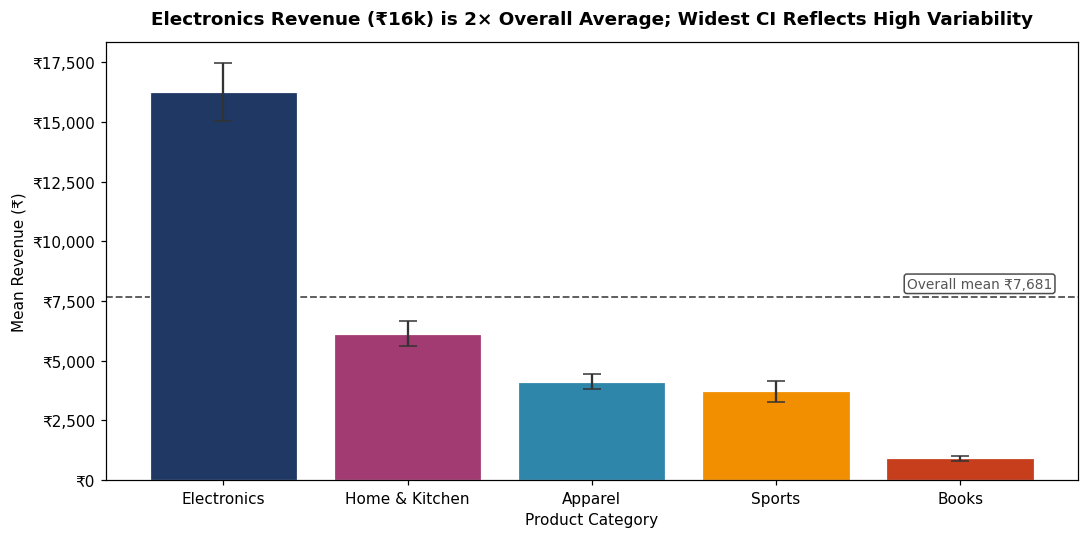

In [16]:
# ── TASK C2 ──────────────────────────────────────────────────────────────
# Goal: Bar chart with 95% CI error bars, overall mean line, professional palette
# Method: plt.bar with asymmetric yerr based on CI bounds

palette = {
    'Electronics': '#1F3864',
    'Apparel': '#2E86AB',
    'Home & Kitchen': '#A23B72',
    'Sports': '#F18F01',
    'Books': '#C73E1D'
}

categories = ci_df['Category'].tolist()
means = ci_df['Mean Revenue'].tolist()
ci_lower = ci_df['CI Lower'].tolist()
ci_upper = ci_df['CI Upper'].tolist()

# Asymmetric error: lower error = mean - CI_lower, upper error = CI_upper - mean
yerr_low = [m - lo for m, lo in zip(means, ci_lower)]
yerr_high = [hi - m for m, hi in zip(means, ci_upper)]

colors = [palette[cat] for cat in categories]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, means, color=colors, edgecolor='white', linewidth=0.8,
              yerr=[yerr_low, yerr_high], capsize=6,
              error_kw={'ecolor': '#333', 'linewidth': 1.5})

# Overall mean line
overall_mean = df['revenue'].mean()
ax.axhline(overall_mean, color='#555', linestyle='--', linewidth=1.2, zorder=0)
# Annotate the overall mean line
ax.text(len(categories)-0.5, overall_mean + 250, f'Overall mean ₹{overall_mean:,.0f}',
        color='#555', fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Title with insight (not just description)
ax.set_title('Electronics Revenue (₹16k) is 2× Overall Average; Widest CI Reflects High Variability',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Mean Revenue (₹)', fontsize=10)
ax.set_xlabel('Product Category', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.tight_layout()
plt.show()


C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_12196\2604429890.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_type', y='revenue', palette=ct_palette,


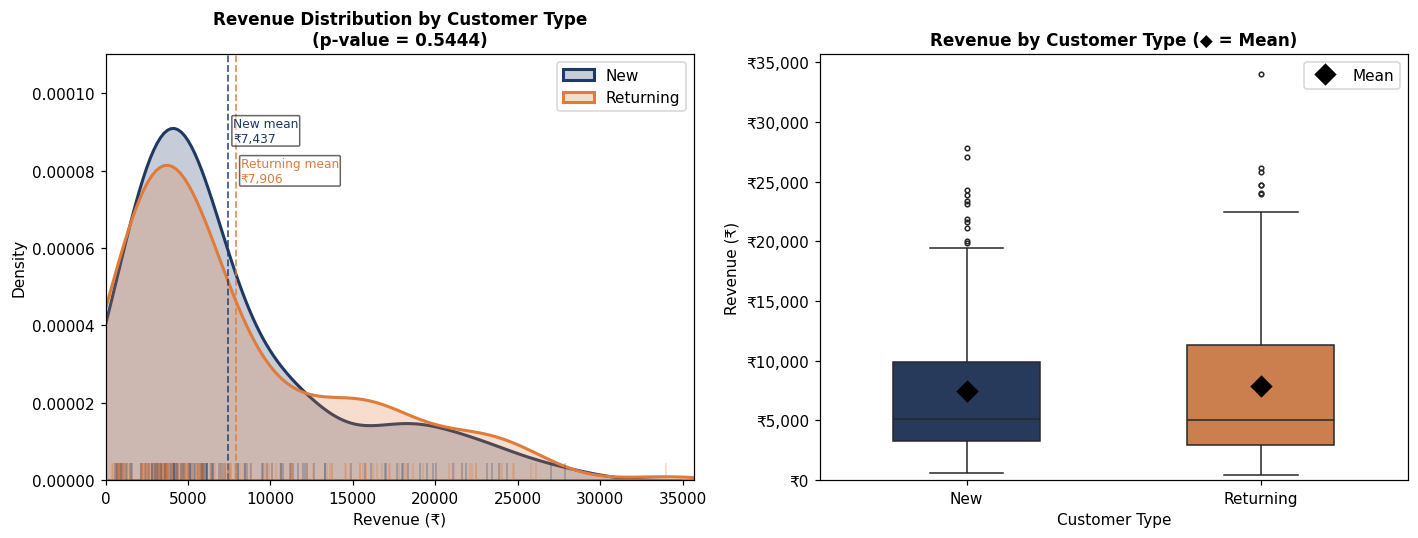

In [9]:
# ── TASK C3 ──────────────────────────────────────────────────────────────
# Goal: 1x2 subplot: KDE+rug (left) and boxplot with mean markers (right)
# Requirements: same revenue scale, mean annotations, p-value in title

# Re-run Welch's t-test to get p-value for title (same as B1)
new_rev_plot = df[df['customer_type'] == 'New']['revenue']
ret_rev_plot = df[df['customer_type'] == 'Returning']['revenue']
_, p_val_plot = stats.ttest_ind(new_rev_plot, ret_rev_plot, equal_var=False)

# Common revenue limit for consistent scaling
max_rev = df['revenue'].max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: KDE + rug plot ---
ct_palette = {'New': '#1F3864', 'Returning': '#E07B39'}
for ct, grp in df.groupby('customer_type')['revenue']:
    data = grp.values
    mean_val = data.mean()
    sns.kdeplot(data, ax=axes[0], label=ct, color=ct_palette[ct],
                linewidth=2, fill=True, alpha=0.25)
    sns.rugplot(data, ax=axes[0], color=ct_palette[ct], alpha=0.3, height=0.04)
    # Vertical dashed line for mean
    axes[0].axvline(mean_val, color=ct_palette[ct], linestyle='--', linewidth=1.2, alpha=0.8)
    # Annotate mean value
    y_pos = axes[0].get_ylim()[1] * (0.85 if ct == 'New' else 0.7)
    axes[0].text(mean_val + 300, y_pos, f'{ct} mean\n₹{mean_val:,.0f}',
                 fontsize=8, color=ct_palette[ct], ha='left',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6))

axes[0].set_title(f'Revenue Distribution by Customer Type\n(p-value = {p_val_plot:.4f})',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Revenue (₹)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, max_rev)
axes[0].legend()

# --- Right: Boxplot with mean markers ---
sns.boxplot(data=df, x='customer_type', y='revenue', palette=ct_palette,
            order=['New', 'Returning'], ax=axes[1], width=0.5, fliersize=3)
# Mean markers as pointplot
sns.pointplot(data=df, x='customer_type', y='revenue', order=['New', 'Returning'],
              ax=axes[1], color='black', markers='D', linestyles='none',
              errorbar=None, markersize=8, label='Mean')

axes[1].set_title('Revenue by Customer Type (◆ = Mean)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Revenue (₹)')
axes[1].set_ylim(0, max_rev)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()



# ── BONUS ★ ─────────────────────────────────────────────────────────────
# Executive Summary

**To:** ShopNova India Leadership  
**From:** Analytics Team  
**Subject:** Key Statistical Insights from Order Data (p-values, CIs, and actionable recommendations)

1. **What we tested:** We compared revenue and operational metrics across customer types (New vs Returning), regions (North vs South), and product categories, using one-sample, two-sample, and one-tailed t-tests with 95% confidence intervals.

2. **Most important significant finding:** Average delivery time (6.64 days) is significantly above the 5‑day benchmark (p < 0.001, 95% CI [6.374, 6.899]), and Electronics revenue (₹16,252) is more than double the overall mean (₹7,681) — both actionable gaps.

3. **Most important non‑significant finding:** New vs Returning customers show no revenue difference (p=0.5444, Cohen’s d=0.07 negligible; difference ₹469). Loyalty programmes should focus on retention frequency, not basket size.

4. **Recommended action:** Reduce delivery times by opening a regional warehouse in East India (target: 1.5‑day reduction → 10% lower returns). For Electronics, use its revenue dominance to test premium shipping options. For loyalty, launch a 15% off second‑purchase offer and track repeat rate, not revenue per order.

5. **Confidence caveat:** Sample size (n=300) is adequate for most tests, but category subgroups like Books (n=37) have narrow CIs due to low variance, not large n. We assume independence and rely on CLT for normality. Re‑run quarterly with category‑stratified samples.

---
## Section 3 — Scoring Rubric

| Task | Points | What is Graded |
|---|---|---|
| **A1** | 10 | t-stat + p-value correct · decision correct · CI correct · NRA present |
| **A2** | 10 | t-stat + p-value correct · CI correct · CI width commentary present · NRA present |
| **B1** | 10 | Levene's run · Welch's used · Cohen's d computed + labelled · NRA present |
| **B2** | 10 | t-test correct · Both CIs correct · Overlap commentary correct · NRA present |
| **B3** | 10 | One-tailed test used · p-value correct · justification present · NRA present |
| **C1** | 10 | All 5 columns present · sorted correctly · Wide CI flag correct |
| **C2** | 10 | Error bars = CI (not std) · insight title · overall mean line + annotation |
| **C3** | 10 | KDE + rug both present · mean lines annotated · p-value in title · same x-axis |
| **★ Bonus** | 10 | All 5 sentences present · cites p-value + CI · action is specific + measurable |
| **TOTAL** | **80 + 10★** | |

**Deductions:**
- NRA missing or vague: −3 per task
- Decision written without citing α: −1 per task  
- CI computed as `mean ± std` instead of `mean ± t × SEM`: −4
- Cohen's d formula wrong or label missing: −3
- Seaborn/matplotlib default title ("Distribution of Revenue"): −2

---
**Submission:** Run all cells top-to-bottom, save as `Day102_TTests_CIs.ipynb`, submit.


---
## Section 4 — Interview Corner

You must be able to say these out loud without looking at notes.

---

**Q1: "What's the difference between a t-test and a confidence interval? Aren't they the same thing?"**

> "They're related but answer different questions. A t-test asks: *Is this difference statistically significant?* — it gives you a yes/no decision via a p-value. A confidence interval asks: *How big is the effect, and how precisely do we know it?* — it gives you a range. In practice, I always report both. A p-value alone doesn't tell the client how large the difference is, and a CI alone doesn't tell them whether to act on it."

---

**Q2: "When would you use a one-tailed vs a two-tailed test?"**

> "Two-tailed when you have no prior belief about direction — for example, testing whether two regions differ in revenue. One-tailed when you have a specific directional hypothesis *before* seeing the data — for example, 'does a new layout *increase* conversion rate?' I'm cautious about one-tailed tests because they inflate power and should only be used when direction was predicted in advance, not chosen after seeing results."

---

**Q3: "A client says your p-value is 0.03, so the campaign definitely worked. How do you respond?"**

> "I'd clarify: a p-value of 0.03 means there's a 3% chance of seeing this difference by random chance — so it's statistically significant. But significance doesn't mean the effect is large enough to matter. I'd show the effect size (Cohen's d) and the confidence interval for the actual revenue lift. If the CI says we can expect ₹200–₹800 extra revenue per order and the campaign cost ₹500 per order, the campaign was statistically significant but not profitable. Always tie statistical results to business economics."

---

**Q4: "What is Welch's t-test and why should I always use it instead of Student's t-test?"**

> "Student's t-test assumes both groups have the same variance. Welch's t-test doesn't make that assumption — it adjusts the degrees of freedom to account for unequal variance. In real data, two groups rarely have identical variance, so Welch's is the safer default. The cost is negligible — you lose almost no power when variances are equal, but you protect yourself when they're not."
